# Mini Project 4

By the deadline (**26.01.2026**), please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, `networkx`...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Traveling Salesperson Problem (TSP) – Heuristic with Transformers

### Introduction

The Traveling Salesperson Problem (TSP) is a classical combinatorial optimization problem: given a set of cities and the distances between them, the goal is to find the shortest possible tour that visits each city exactly once and returns to the starting point. See this picture for reference. 

![TSP](https://optimization.cbe.cornell.edu/images/e/ea/48StatesTSP.png)

TSP is NP-hard, meaning that finding the optimal solution becomes computationally intractable as the number of cities grows. Therefore, in practice, we often rely on heuristic or approximate algorithms to find good solutions in a reasonable time.

In this assignment, your task is to implement a heuristic TSP solver for Euclidean TSP using a Transformer-based model. 

Euclidean TSP is a TSP where all the cities are assumed to be in the Euclidean 2D space and the distance is computed acording to the standard Euclidean norm.

The Transformer architecture, widely used in natural language processing, can also model sequences of nodes in a graph. By training a Transformer on TSP instances, you can generate tours in an autoregressive manner selecting one city at a time based on previously chosen cities.

This assignment will help you to understand how sequence models like Transformers can be applied beyond text, to combinatorial problems and practice autoregressive generation and masking techniques for sequence prediction.

Most of the code is provided. This **does not mean that you are allowed to use it blindly**: make sure to understand what is happening.

In [1]:
import networkx as nx
import torch
import torch.nn as nn
import math
from networkx.algorithms.approximation import greedy_tsp
import numpy as np
import pickle
import torch.optim as optim
from tqdm import tqdm
from typing import List
import pickle
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: mps


In [3]:
#Imo It's much better to keep the hyperparameters all in the same place, also for eventual hyperparam optimization.
# Most HYPERPARAMS are set by the PDF
HYPERPARAMS = {
    "batch_size": 64,
    "num_epochs": 60,
    
    #Model parameters
    "d_model": 128,
    "nhead_encoder": 8,
    "nhead_decoder": 8,
    "n_encoder_layers": 4,
    "n_decoder_layers": 4,
    "dropout": 0.1,
    "d_ff": 4 * 128,
    
    #Learning rate
    "learning_rate": 1e-4,
    #"warmup_epochs": 5,           # Number of epochs for warm-up
    #"scheduler_type": "cosine",   # Type of scheduler ('cosine', 'step', 'plateau') I picked cosine as it helps escape local minima and from repeated testing there seems to be one for loss ~ 2.0 and training gets stuck there for many epochs. This happens also to collegues with different setups.
    #"scheduler_gamma": 0.1,       
    #"scheduler_step_size": 15,    
    #"scheduler_T_max": 45,        # For cosine annealing (total_epochs - warmup_epochs)
    #"scheduler_min_lr": 1e-6,
}


### Task 1 (0 pts)

Learn how to use the [NetworkX](https://networkx.org/documentation/stable/tutorial.html) package. The section on Graphs should be sufficient for this assignment. You can skip the sections on directed graphs and beyond.


### Utility Functions

Below are some utility functions. Detailed explanations are provided in each function’s description. At a high level, these functions do the following:

* `random_tour`: Takes a `networkx.Graph` as input and returns a random tour. This can serve as a simple heuristic, but its performance is generally low, as expected.
* `tour_length`: Takes a `networkx.Graph` and a tour (encoded as a `list` that starts and ends at the same node) and returns the total length of the tour.
* `gap`: Measures the quality of a tour by computing

$$ \dfrac{\text{Estimated} - \text{Optimal}}{\text{Optimal}} $$

As you might expect, lower values are better, with a gap of zero indicating that the tour is exactly optimal.


In [4]:
def random_tour(G: nx.Graph) -> List[int]:
    """
    Generate a random TSP tour for a given graph.

    Parameters
    ----------
    G : networkx.Graph
        A graph representing the TSP instance. Nodes should be numbered from 0 to n-1.

    Returns
    -------
    tour : list of int
        A list of node indices representing a complete tour starting and ending at node 0.
        Each node appears exactly once in the tour (except the start/end node).
    """
    n = G.number_of_nodes()
    tour = [0]
    for _ in range(1, n):
        next_node = np.random.choice([j for j in range(n) if j not in tour]) #doesnt pick closest or anything just pick one with uniform p that hasnt been picked
        tour.append(next_node)
    tour.append(0)
    return tour

def tour_length(G: nx.Graph, tour: List[int]) -> float:
    """
    Compute the total length/cost of a tour in a (weighted) graph.

    Parameters
    ----------
    G : networkx.Graph
        The graph representing the TSP instance.
    tour : list of int
        A list of node indices representing a complete tour starting and ending at node 0.

    Returns
    -------
    length : float
        Sum of edge weights along the tour.
    """
    if len(tour) < 2:
        raise ValueError("Tour must contain at least 2 nodes (start and end).")
    if tour[0] != tour[-1]:
        raise ValueError("Tour must start and end at the same node.") #check arrival = start
    if any(v not in G for v in tour):
        missing = [v for v in tour if v not in G]
        raise ValueError(f"Tour contains nodes not in graph: {missing}")

    total = 0.0
    for u, v in zip(tour[:-1], tour[1:]): #again zip allow for iterating over it at once
        if not G.has_edge(u, v): #check the model is using existing edges
            raise ValueError(f"Tour uses missing edge ({u}, {v}).")
        total += float(G[u][v].get("weight", 1.0)) #add distance

    return total

def gap(estimated : float, optimal : float) -> float:
    """
    Compute the relative optimality gap of a TSP tour.

    Parameters
    ----------
    estimated : float
        The total cost of the computed tour.
    optimal : float
        The cost of the known optimal tour.

    Returns
    -------
    gap : float
        The relative gap between the estimated and optimal cost,
        computed as (estimated - optimal) / optimal.
    """
    return (estimated - optimal) / optimal

### Task 2 (10 pts)

The dataset has already been prepared for your convenience and is split into training, validation, and test sets. Load it using [pickle](https://docs.python.org/3/library/pickle.html).

For this task, focus on the case **$n = 20$**, i.e., solving a TSP with 20 cities. Inspect each item in the dataset: what type is it? You should see that it is a `tuple` consisting of a `networkx` graph and a list representing the optimal tour (our ground truth).

Answer the following questions carefully:

* What does the node attribute `pos` represent?
* What does the edge attribute `weight` represent?
* What does the boolean edge attribute `tour` represent?

Do not proceed until you fully understand each of these components.


In [5]:
with open("data/train_20_DLL_ass4.pkl", "rb") as f:
    train_data = pickle.load(f)

with open("data/valid_20_DLL_ass4.pkl", "rb") as f:
    valid_data = pickle.load(f)

with open("data/test_20_DLL_ass4.pkl", "rb") as f:
    test_data = pickle.load(f)

with open("data/dummy_20_DLL_ass4.pkl", "rb") as f:
    dummy_data = pickle.load(f)


## Inspecting the ds ##

In [6]:
#some inspections
print(type(train_data), len(train_data))

sample = train_data[0]
print(type(sample), len(sample))

G, opt_tour = train_data[0] #<- they re labelled
print(type(G))

print(G.number_of_nodes(), G.number_of_edges()) #<- It's fully connected ! we have all the distances (why then check for using existing edges?)

<class 'list'> 50000
<class 'tuple'> 2
<class 'networkx.classes.graph.Graph'>
20 190


In [7]:
print(G.nodes[0]) # so pos attribute is the coordinates on an euclidean 2d map, and distances are precomputed for us
print(nx.get_node_attributes(G, "pos"))

{'pos': (0.6049077053425551, 0.5748590937018008)}
{0: (0.6049077053425551, 0.5748590937018008), 1: (0.38474987528197846, 0.9428085200806016), 2: (0.6102491981278754, 0.3707527129445174), 3: (0.5497610140601452, 0.514788385568776), 4: (0.5941533303116413, 0.6544475361385552), 5: (0.06187381797691738, 0.433195284467101), 6: (0.7475717305758963, 0.3950876312718402), 7: (0.6548530739834322, 0.06254140180263457), 8: (0.2210796367473482, 0.2142238067774731), 9: (0.6696714621150585, 0.4364218673039507), 10: (0.3206284506117195, 0.7885615893113229), 11: (0.37760295594024584, 0.4963855605324464), 12: (0.8300002368321365, 0.3489482457969727), 13: (0.9983722301898076, 0.2725163812162502), 14: (0.5306200040273271, 0.4146737532387711), 15: (0.2540580284004623, 0.8878378722372976), 16: (0.7024553839343133, 0.2586205516051998), 17: (0.11129635562701035, 0.35987398782201374), 18: (0.33376928628552816, 0.1718375502602505), 19: (0.8952647398936215, 0.6299289412776933)}


In [8]:
print(list(G.edges(data=True))[:5]) #as expected weight are precomp distances. Tour is if taking that edge is part of the optimal solution (tours are invertible)
#so we have double labels, both in the form of opt_tour labels and annotations on edges
print(opt_tour)

[(0, 1, {'weight': 0.4287846201876535, 'tour': 0}), (0, 2, {'weight': 0.20417626260418414, 'tour': 0}), (0, 3, {'weight': 0.08154537102129383, 'tour': 1}), (0, 4, {'weight': 0.08031174728403137, 'tour': 1}), (0, 5, {'weight': 0.5612080164024046, 'tour': 0})]
[0, 3, 14, 2, 9, 6, 19, 13, 12, 16, 7, 18, 8, 17, 5, 11, 10, 15, 1, 4, 0]


### Taks 3 (4 pts)

In this task, you will implement a custom PyTorch Dataset to handle TSP instances. Your dataset should take as input a list of tuples, where each tuple contains:

1. A `networkx` graph representing the cities and their distances.
2. A list representing the optimal tour (ground truth).

You should implement a class `TSPDataset` that returns, for a given index `idx`, a tuple `(X, opt_tour)` where:

  * `X` is a tensor of shape `[n_nodes, 2]` containing the coordinates of each node (from the node attribute `pos`).
  * `opt_tour` is a tensor containing the optimal tour as a sequence of node indices.

Then, create a dataset object for both training, validation and test sets.

In [9]:
#-----------DS Class-----------
class TSPDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        G, opt_tour = self.data[idx]

        n = G.number_of_nodes()

        # Extract node positions in index order
        pos = nx.get_node_attributes(G, "pos")
        X = []
        for i in range(n):
            X.append(torch.tensor(pos[i], dtype=torch.float32))
        X = torch.stack(X)  # shape [n_nodes, 2]

        # Optimal tour as tensor
        opt_tour = torch.tensor(opt_tour, dtype=torch.long)

        return X, opt_tour  

In [10]:
#Calls
train_dataset = TSPDataset(train_data)
valid_dataset = TSPDataset(valid_data)
test_dataset  = TSPDataset(test_data)


In [11]:
#Check
X, y = train_dataset[0]
print(X.shape, y.shape)

torch.Size([20, 2]) torch.Size([21])


### Task 4 (3 pts)

Create the `Dataloader` objects for training and validation. Probably you just need training and validation loader.

In [12]:
#----------Loaders-----------
batch_size = HYPERPARAMS['batch_size']

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [13]:
#Check again
X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape, y_batch.shape) #<- check the expected size 64 batch len, 20 nodes, 2 coords. for the opt it's 21 because it return to itself.

torch.Size([64, 20, 2]) torch.Size([64, 21])


### Task 5 (5 pts)

Implement Positional encoding for sequence models. Positional encoding allows a Transformer to incorporate information about the order of elements in a sequence, since the model itself is permutation-invariant.

You are asked to implement a function/a class that takes as input:

  * `seq_len`: the length of the sequence (number of positions).
  * `embed_dim`: the dimensionality of the embedding vectors.

And returns a tensor of shape `[seq_len, embed_dim]`, where each row corresponds to the positional encoding vector for a position in the sequence.

In [14]:
#----------Positional encoding-----------
#I ve implemented both so i can check which one works best and ditch the other.
 #Option 1 (og synusoidal encoding)
def positional_encoding(seq_len, embed_dim):
    pe = torch.zeros(seq_len, embed_dim)

    position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, embed_dim, 2, dtype=torch.float32)
        * (-math.log(10000.0) / embed_dim)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

# Option 2 (learnable weights)
class PositionalEncoding(nn.Module):
    def __init__(self, max_seq_len, embed_dim):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        pos_emb = self.pos_embedding(positions)
        return x + pos_emb.unsqueeze(0)


### Task 6 (30 pts)

In this task, you are asked to implement a Transformer-like architecture. You have two options:

1. Implement the architecture provided in the pdf and sketched with guidance in the next cell. This option is fully guided, however, following it exactly will give you full points.

2. Implement your own Transformer-based architecture. You are free to design it as you wish, as long as it is Transformer-based. No extra points will be awarded for choosing this option, but full points can still be earned if it works correctly.

Choose the approach that best suits your preference and experience.

In [ ]:
class TSPTransformer(nn.Module):
    def __init__(self,
        n: int,
        d_model: int,
        d_ff: int,
        nhead_encoder: int,
        nhead_decoder: int,
        n_encoder_layers: int,
        n_decoder_layers: int,
        dropout: float = 0.1,
        

    ):
        super().__init__()
        
        # stored, used also in the forward
        self.n = n  # Number of nodes
        self.d_model = d_model #hidden dimension (inside transformer)
        self.d_ff = d_ff #dimension of the feedforward layer inside transformer blocks.
        
        ######################################
        # Feature expansion
        #####################################
        # Linear layer to project 2D coordinates to d-dimensional space
        self.feature_expansion = nn.Linear(2, d_model)
        
        # node embedding
        self.embedding = nn.Embedding(n, d_model)
        
        ######################################
        # Encoder
        #####################################
        # Encoder layer
        encoder_layer = nn.TransformerEncoderLayer( #the academic version of encoder
            d_model=d_model,
            nhead=nhead_encoder,#n attention heads
            dim_feedforward= d_ff,
            dropout=dropout,
            batch_first=False  # PyTorch Transformer uses (seq_len, batch, features) by default
        )
        
        # Encoder
        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=n_encoder_layers
        ) #stakcs multiple layers

        ######################################
        # Optional linear map after encoder
        #####################################
        self.encoder_out_linear = nn.Linear(d_model, d_model)

        ######################################
        # Decoder
        #####################################
        
        #Positional Encoding
        self.positional_encoding = nn.Embedding(n, d_model)
        
        # Decoder layer
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead_decoder,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=False
        )
        
        # Decoder
        self.decoder = nn.TransformerDecoder(
            decoder_layer=decoder_layer,
            num_layers=n_decoder_layers
        )
        
        ######################################
        # Output linear layer
        #####################################
        self.output_linear = nn.Linear(d_model, n)

        # Initialize the weight as commonly done for the LLMs
        self.apply(self.init_weights)

    def forward(self, X, src):
        """
        X: Input coordinates [batch_size, n, 2]
        src: Source sequence (partial tour) [batch_size, seq_len]
        """
        batch_size = X.shape[0]
        
        # Feature expansion: project 2D coordinates to d_model dimensions
        # [batch_size, n, 2] -> [batch_size, n, d_model]
        coord_features = self.feature_expansion(X)
        
        # Add node embeddings (shared between encoder and decoder)
        # Create node indices [0, 1, ..., n-1]
        #node_indices = torch.arange(self.n, device=X.device).expand(batch_size, self.n)
        # [batch_size, n, d_model]
        
        #---------Encoder-------------
        # Combine coordinate features and node embeddings
        # Add node embeddings to encoder input
        node_indices = torch.arange(self.n, device=X.device).unsqueeze(0).expand(batch_size, self.n)
        encoder_input = coord_features + self.embedding(node_indices)
        encoder_input = encoder_input * math.sqrt(self.d_model)  # Add scaling to keep embedings similar in magnitude to attention
        
        # Reshape for Transformer: [n, batch_size, d_model]
        encoder_input = encoder_input.transpose(0, 1)
        
        # Pass through encoder
        memory = self.encoder(encoder_input)
        
        # Optional linear map after encoder
        memory = self.encoder_out_linear(memory)
        
        # Prepare decoder input
        # src: [batch_size, seq_len] -> get embeddings
        #decoder_input_embeds = self.embedding(src)   # [batch_size, seq_len, d_model]
        
        #Positional encoding
        seq_len = src.shape[1]
        pos_encoding = positional_encoding(seq_len, self.d_model).to(X.device)
        decoder_input = self.embedding(src) + pos_encoding.unsqueeze(0).expand(batch_size, -1, -1)
        decoder_input = decoder_input * math.sqrt(self.d_model)  # scaling again

        
        # Reshape for Transformer: [seq_len, batch_size, d_model]
        decoder_input = decoder_input.transpose(0, 1)
        
        # Create mask for decoder (causal mask)
        tgt_mask = self.create_mask(seq_len).to(X.device)
        
        # Pass through decoder
        decoder_output = self.decoder(
            tgt=decoder_input,
            memory=memory,
            tgt_mask=tgt_mask
        )
        
        # Reshape back: [seq_len, batch_size, d_model] -> [batch_size, seq_len, d_model]
        decoder_output = decoder_output.transpose(0, 1)
        
        # Final linear layer to get logits for next node
        output = self.output_linear(decoder_output)  # [B, seq_len, n]

        #visited = torch.zeros_like(output, dtype=torch.bool)

        #batch_size, seq_len, _ = output.shape
        #visited_mask = torch.zeros(batch_size, seq_len, self.n, 
                                #device=output.device, dtype=torch.bool)
        
        #for t in range(seq_len):
           # if t > 0:  # Don't mask first prediction
                # Mark all nodes visited before current step
                #visited_mask[:, t, :] = False
                #for b in range(batch_size):
                  #  visited_mask[b, t, src[b, :t]] = True
    
        #output = output.masked_fill(visited, -1e9)
  
        return output

    def create_mask(self, seq_len):
        """
        Create a causal mask for the decoder.
        This ensures that position i can only attend to positions <= i.
        """
        # Create a square matrix where upper triangle is True (to be masked)
        mask = torch.triu(torch.ones((seq_len, seq_len), device=DEVICE) * float('-inf'), diagonal=1) 
        return mask
        
    def init_weights(self, m):
        """
        Initialize weights as commonly done for LLMs.
        Following Transformer standard initialization.
        """
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

        elif isinstance(m, (nn.TransformerEncoderLayer, nn.TransformerDecoderLayer)):
            for p in m.parameters():
                if p.dim() > 1:
                    nn.init.normal_(p, mean=0.0, std=0.02)


### Task 7 (35 pts)

Train your model. Plot training and validation loss, clearly showing no overfitting.

In [16]:
#-----------Set-up-------------------
model = TSPTransformer(
    n=20,  # For n=20 TSP
    d_model=HYPERPARAMS['d_model'],
    d_ff=HYPERPARAMS['d_ff'],
    nhead_encoder=HYPERPARAMS['nhead_encoder'],
    nhead_decoder=HYPERPARAMS['nhead_decoder'],
    n_encoder_layers=HYPERPARAMS['n_encoder_layers'],
    n_decoder_layers=HYPERPARAMS['n_decoder_layers'],
    dropout=HYPERPARAMS['dropout']
).to(DEVICE)

# AdamW optimizer as per PDF
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HYPERPARAMS['learning_rate']
)

# scheduler setup
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#    optimizer,
 #   T_0=HYPERPARAMS['warmup_epochs'],
 #   T_mult=1,
#    eta_min=HYPERPARAMS['scheduler_min_lr']
#)
# Loss function: cross-entropy as per PDF
criterion = nn.CrossEntropyLoss()

/opt/miniconda3/envs/averageML/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
#-----------------Helper function for train/eval again------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X, opt_tour in loader:
        X = X.to(device)                       # [B, n, 2]
        opt_tour = opt_tour.to(device)         # [B, n+1]

        # Teacher forcing (we ignore the predicted nodes and always feed the ground truth)
        decoder_input = opt_tour[:, :-1]       # [B, n]
        targets = opt_tour[:, 1:]               # [B, n]

        optimizer.zero_grad()

        logits = model(X, decoder_input)        # [B, n, n]

        # Flatten for CE
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),   # [B*n, n]
            targets.reshape(-1)                     # [B*n]
        )

        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X, opt_tour in loader:
        X = X.to(device)
        opt_tour = opt_tour.to(device)

        decoder_input = opt_tour[:, :-1]
        targets = opt_tour[:, 1:]

        logits = model(X, decoder_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / len(loader)


In [18]:
num_epochs = HYPERPARAMS['num_epochs']

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss = validate_one_epoch(
        model, valid_loader, criterion, DEVICE
    )
    #scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

Epoch 001 | Train loss: 2.8042 | Val loss: 2.7051
Epoch 002 | Train loss: 2.5198 | Val loss: 2.3181
Epoch 003 | Train loss: 2.2346 | Val loss: 2.1572
Epoch 004 | Train loss: 2.1419 | Val loss: 2.0701
Epoch 005 | Train loss: 2.0487 | Val loss: 2.0000
Epoch 006 | Train loss: 2.0206 | Val loss: 1.9931
Epoch 007 | Train loss: 2.0129 | Val loss: 1.9911
Epoch 008 | Train loss: 2.0077 | Val loss: 1.9850
Epoch 009 | Train loss: 2.0032 | Val loss: 1.9857
Epoch 010 | Train loss: 2.0006 | Val loss: 1.9865
Epoch 011 | Train loss: 1.9980 | Val loss: 1.9827
Epoch 012 | Train loss: 1.9954 | Val loss: 1.9813
Epoch 013 | Train loss: 1.9940 | Val loss: 1.9816
Epoch 014 | Train loss: 1.9924 | Val loss: 1.9806
Epoch 015 | Train loss: 1.9908 | Val loss: 1.9793
Epoch 016 | Train loss: 1.9894 | Val loss: 1.9794
Epoch 017 | Train loss: 1.9880 | Val loss: 1.9802
Epoch 018 | Train loss: 1.9872 | Val loss: 1.9796
Epoch 019 | Train loss: 1.9861 | Val loss: 1.9801
Epoch 020 | Train loss: 1.9852 | Val loss: 1.9794


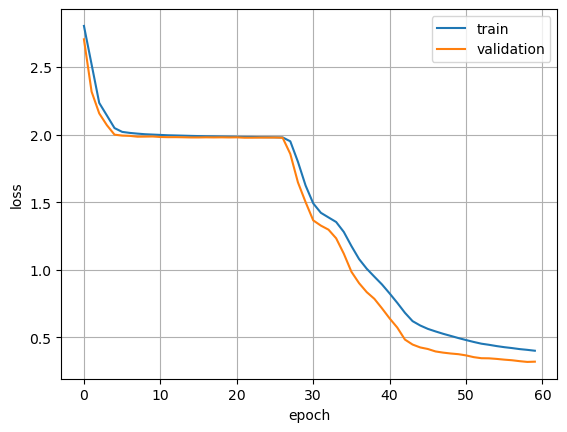

In [19]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()


### Task 8 (3 pts)

Finally, evaluate your model as if it were a heuristic for solving the TSP. Compare its performance with other simple baselines, such as:

* A random tour sampled uniformly at random
* The greedy heuristic, where you start from a given city and repeatedly move to the closest unvisited one. Its theoretical performance guarantees are quite weak, but in practice it can sometimes work surprisingly well.

The code needed to run these baselines is already provided in the next cells. There is just something you may want to check in the second cell after this one.
Before using it, make sure you fully understand what each part of the provided code is doing.

At the very end, you should see something like this, with our trained model beating all the baselines:

```
Greedy TSP average gap: 0.171123
Random TSP average gap: 1.745515
Our TSP average gap: 0.05374
```



In [20]:
def transformer_tsp(G, model, start_node = 0, DEVICE="cpu"):
    """
    Evaluate a trained Transformer-based TSP heuristic on a given graph G.

    This function performs greedy autoregressive decoding: starting from node 0,
    it repeatedly queries the model to predict the next city to visit, always
    selecting the highest-scoring unvisited node. The predicted tour is finally
    closed by returning to the starting point.

    Parameters
    -----------
        G (networkx.Graph):
            A TSP instance where each node has a 'pos' attribute containing its
            2D coordinates.
        model (torch.nn.Module):
            A trained Transformer-like neural network that takes:
                - x: a tensor of node coordinates  
                - y: the partial tour so far       
              and outputs logits for the next node at each decoding step.
        start_node (int):
            The starting node; default is zero.
        DEVICE (str, optional):
            Device to run the model on (“cpu” or “cuda” (<-- GPU)). Default is "cpu".

    Returns:
    --------
        float:
            The length of the predicted tour, computed using `tour_length`.
    """

    # Set the model in evaluation mode (important for layers like dropout)
    model.eval()

    # Number of nodes
    n = G.number_of_nodes()

    # Extract node coordinates into a tensor of shape [n, 2]
    attr = nx.get_node_attributes(G, "pos")
    x = []
    for i in range(n):
        x.append(torch.tensor(attr[i], dtype=torch.float32))
    x = torch.stack(x)

    # Initial tour starts at node 0
    tour = [start_node]
    y = torch.tensor(tour, dtype=torch.long)

    # Move tensors to the desired device and add batch dimension
    x = x.to(DEVICE).unsqueeze(0)
    y = y.to(DEVICE).unsqueeze(0)

    # First forward pass
    out = model(x, y)

    # Autoregressive greedy decoding
    while len(tour) < n:
        # Get nodes sorted by descending score
        _, idx = torch.topk(out, n, dim=2)

        # Pick the highest-scoring unvisited node
        for i in range(n):
            if idx[0, -1, i] not in tour:
                tour.append(idx[0, -1, i])
                break

        # Update decoder input and run model again
        y = torch.tensor(tour, dtype=torch.long).to(DEVICE).unsqueeze(0)
        out = model(x, y)

    # Close the tour by returning to the starting node
    tour = [int(i) for i in tour] + [start_node]

    # Compute and return its length
    return tour_length(G, tour)

In [21]:
"""
TODO
1. Load / Use the model you want to use (I guess, your best/last model)

2. Have you loaded the training data?
"""


'\nTODO\n1. Load / Use the model you want to use (I guess, your best/last model)\n\n2. Have you loaded the training data?\n'

In [22]:
model.eval()
X_test = test_data

optimal_tours_values = []
greedy_tsp_values = []
random_tsp_values = []
our_heuristic_values = []

for idx, (G, y_opt) in tqdm(enumerate(X_test), total=len(X_test)):
    # OPT
    optimal_tours_values.append(tour_length(G, y_opt))

    # Greedy TSP
    tour_greedy = greedy_tsp(G)
    greedy_tsp_values.append(tour_length(G, tour_greedy))

    # Random TSP
    tour_random = random_tour(G)
    random_tsp_values.append(tour_length(G, tour_random))

    # Our Heuristic
    our_heuristic_values.append(transformer_tsp(G, model, DEVICE=DEVICE))

100%|██████████| 1000/1000 [08:17<00:00,  2.01it/s]


In [23]:
# Greedy TSP gap
gaps_greedy = []
for i in range(len(X_test)):
    gap_greedy = gap(greedy_tsp_values[i], optimal_tours_values[i])
    gaps_greedy.append(gap_greedy)
print("Greedy TSP average gap:", np.mean(gaps_greedy), flush=True)

# Random TSP gap
gaps_random = []
for i in range(len(X_test)):
    gap_random = gap(random_tsp_values[i], optimal_tours_values[i])
    gaps_random.append(gap_random)
print("Random TSP average gap:", np.mean(gaps_random), flush=True)

# Our Heuristic
gaps_our = []
for i in range(len(X_test)):
    gap_our = gap(our_heuristic_values[i], optimal_tours_values[i])
    gaps_our.append(gap_our)#gap_random -> gap_our !!!! otherwise it prints the random gap!
print("Our TSP average gap:", np.mean(gaps_our), flush=True)

Greedy TSP average gap: 0.1711230744772561
Random TSP average gap: 1.735044955834012
Our TSP average gap: 0.05539081732429942


#  

## Questions

1. Can you use this model for a TSP instance with 50 nodes? How can you improve it?

No because it is like using words not in the dictionary. Also attention is o(n^2), it exist fast-attention which makes it linear. need to retrain, not embed nodeID and use the coordinates alone. 

2. What is attention and why is it the core mechanism of Transformers?

check if other tokens are relevant, useful to context, query-key value thing softmax(QK/key_lenght)V matrixes are params. in self you get it from self, in cross you get query from decoder.

3. How does multi-head attention differ from single-head attention? Why is it useful?

You do multiple attention steps at ones to check for different semantic meanings (some shorter some longer etc). you concatenate the output as they re d/n_heads  

4. What is the purpose of positional encodings in a Transformer? Why are they needed?

it encodes information about the position of the token so model knows what is where

5. Describe the role of the feed-forward network inside each Transformer layer.

Attention just tell us how to aggregate things/what is more important. Several studies show that FFNs store long-term, factual or pattern-based information, acting as an associative memory. ps the nonlinear things have been moved around a bit in history to optimize.

6. Why do Transformers use Layer Normalization instead of Batch Normalization?

batch use statistics over batch, which is fine for cnn as data is iid, batches are large ecc. layer does this one token at a time, ideal for decoder inference when we re predicting one token after the other

7. What are Q, K, and V? Explain their dimensions intuitively.

Mechanically, given an input embedding of dimension d_model, for each token you apply three learned linear projections:
Q = X W_Q
K = X W_K
V = X W_V
d_k = d_v = d_model / h, where h is the number of attention heads.
Assume a batch size B, a sequence length L, and a model dimension d_model. After projection, Q, K, and V have shape:
B × L × d_k for Q and K and B × L × d_v for V

8. Why do we scale the dot product by √dₖ in scaled dot-product attention?

Because without scaling, the dot products between queries and keys grow with the dimension dₖ, which makes training unstable.

9. What is the intuition behind causal masking?

the autoregressive constraint: when predicting the next token, the model can only use past and present information.

11. What is the difference between training-time input and inference-time input in autoregressive models? What is teacher forcing? Why is it used?

Training-time input:
The model receives the ground-truth previous tokens as input.
Inference-time input:
The model receives its own previously generated tokens.

12. What is tokenization and why does it matter for LLM performance?

split word adn sentences in bits that are the smallest units used in llm. everything work on tokens as tokens are embedded.

13. What is the difference between pretraining and finetuning?

pretraining is done first and is used to give the model general knowledge on human language, finetuning is done in a successive step to tune for a specific task

14. Explain greedy decoding vs. sampling vs. beam search.

greedy pick highest prob, pling sample from prob distribution, beam search keep top b, for each generate a sequence, then keep b and so on